In [2]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 MB 1.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score,f1_score
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
train_transaction = pd.read_csv("/content/drive/MyDrive/train_transaction.csv")
train_identity = pd.read_csv("/content/drive/MyDrive/train_identity.csv")

train = train_transaction.merge(train_identity, on="TransactionID", how="left")

In [5]:
from google.colab import files

# 1. Reduce the dataframe to 1/4 of its size
# Using random_state=42 ensures you get the exact same random sample if you run this cell again
train_quarter = train.sample(frac=0.25, random_state=42)

# 2. Save the sampled data to a CSV file in Colab
file_name = 'train_quarter.csv'
train_quarter.to_csv(file_name, index=False)

# 3. Download the file to your local computer
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
train_quarter["isFraud"].value_counts()

,count
isFraud,
0,142330
1,5305


In [7]:
train_quarter.shape

(147635, 434)

In [8]:
train.shape

(590540, 434)

In [9]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [10]:
train.tail()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590539,3577539,0,15811131,279.95,W,15066,170.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
nul_val=train.isnull().sum()
print(nul_val)

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
id_36             449555
id_37             449555
id_38             449555
DeviceType        449730
DeviceInfo        471874
Length: 434, dtype: int64


In [12]:
cols_name=train.columns
print(cols_name)

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='object', length=434)


In [13]:
per_of_Fr_NFr=train["isFraud"].value_counts()/len(train)*100
print(per_of_Fr_NFr)

isFraud
0    96.500999
1     3.499001
Name: count, dtype: float64


In [14]:

train['TransactionDT'] = pd.to_datetime(train['TransactionDT'], unit='s')
train['DT_hour'] = train['TransactionDT'].dt.hour
train['DT_day'] = train['TransactionDT'].dt.day
train['DT_weekday'] = train['TransactionDT'].dt.weekday


In [15]:
train.tail()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,DT_hour,DT_day,DT_weekday
590535,3577535,0,1970-07-02 23:57:27,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,2,3
590536,3577536,0,1970-07-02 23:57:29,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,2,3
590537,3577537,0,1970-07-02 23:57:59,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,2,3
590538,3577538,0,1970-07-02 23:58:08,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,2,3
590539,3577539,0,1970-07-02 23:58:51,279.95,W,15066,170.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,2,3


In [16]:
train = train.sort_values(['card1', 'TransactionDT'])

train['time_diff'] = train.groupby('card1')['TransactionDT'].diff().dt.total_seconds()

train['time_diff'] = train['time_diff'].fillna(-1)


In [17]:
agg_funcs = ['count', 'mean', 'std']

for col in ['card1', 'card2']:
    for func in agg_funcs:
        train[f'{col}_{func}_amt'] = train.groupby(col)['TransactionAmt'].transform(func)

In [18]:

resolution_split = train['id_33'].str.split('x', expand=True)

train['screen_width'] = resolution_split[0].astype(float)
train['screen_height'] = resolution_split[1].astype(float)

train = train.drop('id_33', axis=1)

train['browser_clean'] = train['id_31'].str.lower()

major_browsers = ['chrome', 'safari', 'firefox', 'edge', 'ie', 'samsung']

for browser in major_browsers:
    train.loc[train['browser_clean'].str.contains(browser, na=False), 'browser_clean'] = browser


In [19]:
train.tail()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,time_diff,card1_count_amt,card1_mean_amt,card1_std_amt,card2_count_amt,card2_mean_amt,card2_std_amt,screen_width,screen_height,browser_clean
432314,3419314,0,1970-05-07 14:23:24,232.47,W,18395,543.0,150.0,mastercard,224.0,...,1032840.0,11,71.685455,80.187451,5451.0,140.572887,237.800884,NaN,NaN,NaN
433746,3420746,0,1970-05-07 21:49:12,36.95,W,18395,543.0,150.0,mastercard,224.0,...,26748.0,11,71.685455,80.187451,5451.0,140.572887,237.800884,NaN,NaN,NaN
459622,3446622,0,1970-05-17 15:41:49,36.95,W,18395,543.0,150.0,mastercard,224.0,...,841957.0,11,71.685455,80.187451,5451.0,140.572887,237.800884,NaN,NaN,NaN
493204,3480204,0,1970-05-29 21:45:37,36.95,W,18395,543.0,150.0,mastercard,224.0,...,1058628.0,11,71.685455,80.187451,5451.0,140.572887,237.800884,NaN,NaN,NaN
115181,3102181,0,1970-01-26 19:51:41,100.00,R,18396,111.0,150.0,visa,226.0,...,-1.0,1,100.000000,NaN,45191.0,148.895888,242.668837,NaN,NaN,ie


In [20]:

train['uid'] = train['card1'].astype(str) + '_' + train['addr1'].astype(str)
train['uid2'] = train['uid'] + '_' + train['P_emaildomain'].astype(str)

train['uid2_TransactionAmt_count'] = train.groupby('uid2')['TransactionAmt'].transform('count')
train['uid2_TransactionAmt_mean'] = train.groupby('uid2')['TransactionAmt'].transform('mean')
train['uid2_TransactionAmt_std'] = train.groupby('uid2')['TransactionAmt'].transform('std')

train = train.drop(['uid', 'uid2'], axis=1, errors='ignore')


In [21]:
num_cols = train.select_dtypes(include=['int64','float64']).columns
train[num_cols] = train[num_cols].fillna(-999)

object_cols = train.select_dtypes(include=['object']).columns
train[object_cols] = train[object_cols].fillna('missing')

In [22]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,card1_std_amt,card2_count_amt,card2_mean_amt,card2_std_amt,screen_width,screen_height,browser_clean,uid2_TransactionAmt_count,uid2_TransactionAmt_mean,uid2_TransactionAmt_std
243924,3230924,0,1970-03-08 23:36:59,23.443,C,1000,555.0,185.0,mastercard,224.0,...,-999.000000,41995.0,125.703550,205.944022,-999.0,-999.0,chrome,1,23.443000,-999.000000
36634,3023634,0,1970-01-11 14:31:08,183.000,W,1001,555.0,150.0,visa,226.0,...,89.494879,41995.0,125.703550,205.944022,-999.0,-999.0,missing,3,79.666667,89.494879
164336,3151336,0,1970-02-10 13:23:00,29.000,W,1001,555.0,150.0,visa,226.0,...,89.494879,41995.0,125.703550,205.944022,-999.0,-999.0,missing,3,79.666667,89.494879
223739,3210739,0,1970-03-03 00:00:58,27.000,W,1001,555.0,150.0,visa,226.0,...,89.494879,41995.0,125.703550,205.944022,-999.0,-999.0,missing,3,79.666667,89.494879
33767,3020767,0,1970-01-10 18:07:01,150.000,R,1004,583.0,150.0,visa,226.0,...,93.577775,21803.0,233.006049,378.876696,3840.0,2160.0,chrome,1,150.000000,-999.000000


In [23]:
per_nul_val=train.isnull().sum()/len(train)*100
print(per_nul_val)

TransactionID                0.0
isFraud                      0.0
TransactionDT                0.0
TransactionAmt               0.0
ProductCD                    0.0
                            ... 
screen_height                0.0
browser_clean                0.0
uid2_TransactionAmt_count    0.0
uid2_TransactionAmt_mean     0.0
uid2_TransactionAmt_std      0.0
Length: 449, dtype: float64


In [24]:
low_card_thresh = 10
for col in object_cols:
    if train[col].nunique() <= low_card_thresh:
        dummies = pd.get_dummies(train[col], prefix=col, dummy_na=True)
        train = pd.concat([train, dummies], axis=1)
        train = train.drop(col, axis=1)
    else:
        freq = train[col].value_counts() / len(train)
        train[col] = train[col].map(freq)

In [25]:
train.tail()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,id_37_missing,id_37_nan,id_38_F,id_38_T,id_38_missing,id_38_nan,DeviceType_desktop,DeviceType_missing,DeviceType_mobile,DeviceType_nan
432314,3419314,0,1970-05-07 14:23:24,232.47,18395,543.0,150.0,224.0,123.0,87.0,...,True,False,False,False,True,False,False,True,False,False
433746,3420746,0,1970-05-07 21:49:12,36.95,18395,543.0,150.0,224.0,327.0,87.0,...,True,False,False,False,True,False,False,True,False,False
459622,3446622,0,1970-05-17 15:41:49,36.95,18395,543.0,150.0,224.0,327.0,87.0,...,True,False,False,False,True,False,False,True,False,False
493204,3480204,0,1970-05-29 21:45:37,36.95,18395,543.0,150.0,224.0,327.0,87.0,...,True,False,False,False,True,False,False,True,False,False
115181,3102181,0,1970-01-26 19:51:41,100.00,18396,111.0,150.0,226.0,126.0,87.0,...,False,False,False,True,False,False,True,False,False,False


In [26]:
train = train.sort_values('TransactionDT')

cols_to_drop = ['isFraud', 'TransactionID', 'TransactionDT', 'TransactionDT_Real']

X = train.drop(cols_to_drop, axis=1, errors='ignore')
y = train['isFraud']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, shuffle=False)


In [27]:
xgb_model = xgb.XGBClassifier(
    n_estimators=5000,
    learning_rate=0.008,
    max_depth=40,
    subsample=0.8,
    colsample_bytree=0.7,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='auc',
    early_stopping_rounds=50,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=50
)

[0]	validation_0-auc:0.84074
[50]	validation_0-auc:0.91489
[100]	validation_0-auc:0.91950
[150]	validation_0-auc:0.92138
[200]	validation_0-auc:0.92202
[250]	validation_0-auc:0.92302
[300]	validation_0-auc:0.92369
[350]	validation_0-auc:0.92486
[400]	validation_0-auc:0.92565
[450]	validation_0-auc:0.92675
[500]	validation_0-auc:0.92748
[550]	validation_0-auc:0.92840
[600]	validation_0-auc:0.92895
[650]	validation_0-auc:0.92965
[700]	validation_0-auc:0.93013
[750]	validation_0-auc:0.93059
[800]	validation_0-auc:0.93110
[850]	validation_0-auc:0.93150
[900]	validation_0-auc:0.93183
[950]	validation_0-auc:0.93221
[1000]	validation_0-auc:0.93251
[1050]	validation_0-auc:0.93268
[1100]	validation_0-auc:0.93292
[1150]	validation_0-auc:0.93307
[1200]	validation_0-auc:0.93322
[1250]	validation_0-auc:0.93338
[1300]	validation_0-auc:0.93351
[1350]	validation_0-auc:0.93367
[1400]	validation_0-auc:0.93380
[1450]	validation_0-auc:0.93388
[1500]	validation_0-auc:0.93403
[1550]	validation_0-auc:0.93409

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.008, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=40,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=5000,
              n_jobs=None, num_parallel_tree=None, ...)

In [28]:
y_pred_prob = xgb_model.predict_proba(X_valid)[:,1]
y_pred = (y_pred_prob > 0.0028).astype(int)

roc = roc_auc_score(y_valid, y_pred_prob)
recall = recall_score(y_valid, y_pred)
f1 = f1_score(y_valid, y_pred)

print(f"ROC-AUC: {roc:.4f}")
print(f"Recall: {recall:.4f}")

ROC-AUC: 0.9342
Recall: 0.8917


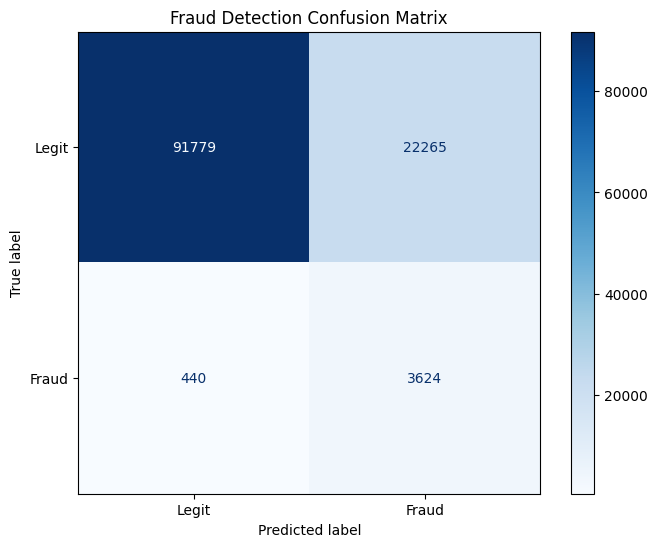

In [29]:

cm = confusion_matrix(y_valid, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])

disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')

plt.title('Fraud Detection Confusion Matrix')
plt.show()

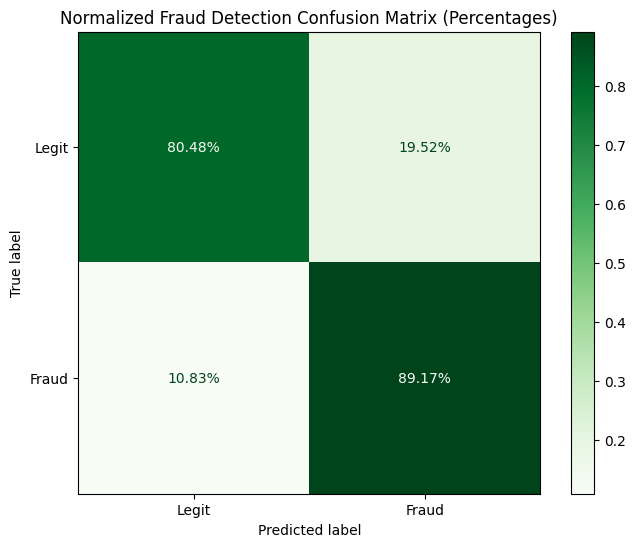

In [30]:

cm = confusion_matrix(y_valid, y_pred)

cm_normalized = confusion_matrix(y_valid, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=['Legit', 'Fraud'])

disp.plot(ax=ax, cmap=plt.cm.Greens, values_format='.2%')

plt.title('Normalized Fraud Detection Confusion Matrix (Percentages)')
plt.show()

In [31]:
xgb_model.save_model("xgb_model.json")

In [32]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.6/208.6 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 135.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: blinker
    Found existing installation: blinker 1.4
error: uninstall-distutils-installed-package

× Cannot uninstall blinker 1.4
╰─> It is a distutils installed project and thus we cannot accurately determine which files belong to it which would lead to only a partial uninstall.


In [33]:
%%writefile pipeline.py
import pandas as pd
import numpy as np
import json

def preprocess_data(df):
    df_clean = df.copy()

    if 'TransactionDT' in df_clean.columns:
        df_clean['TransactionDT_parsed'] = pd.to_datetime(df_clean['TransactionDT'], unit='s')



    try:
        with open('freq_mappings.json', 'r') as f:
            freq_mappings = json.load(f)
    except FileNotFoundError:
        print("Error: freq_mappings.json not found. Make sure it is in the Colab folder.")
        return df_clean

    obj_cols = [col for col in df_clean.columns if df_clean[col].dtype == 'object']
    low_card_thresh = 10

    for col in obj_cols:
        if df_clean[col].nunique() <= low_card_thresh:

            dummies = pd.get_dummies(df_clean[col], prefix=col, dummy_na=True)
            df_clean = pd.concat([df_clean, dummies], axis=1)
            df_clean = df_clean.drop(col, axis=1)
        else:

            if col in freq_mappings:
                df_clean[col] = df_clean[col].map(freq_mappings[col]).fillna(0)
            else:

                df_clean[col] = 0


    cols_to_drop = ['TransactionID', 'TransactionDT', 'TransactionDT_parsed']
    df_clean = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns], errors='ignore')

    return df_clean

Writing pipeline.py


In [34]:
%%writefile app.py
import streamlit as st
import pandas as pd
import xgboost as xgb
from pipeline import preprocess_data

st.set_page_config(page_title="Fraud Detection App", layout="wide")
st.title("Credit Card Fraud Detection")
st.write("Upload your transaction CSV file to generate fraud predictions.")

@st.cache_resource
def load_model():
    model = xgb.XGBClassifier()

    model.load_model("xgb_model.json")
    return model


try:
    model = load_model()
except:
    st.error("Model file 'xgb_model.json' not found. Please upload it to Colab files.")
    st.stop()

uploaded_file = st.file_uploader("Upload CSV Data", type=["csv"])

if uploaded_file is not None:
    st.info("Loading data...")
    df_raw = pd.read_csv(uploaded_file)

    with st.expander("Preview Raw Data"):
        st.dataframe(df_raw.head())

    st.info("Running feature engineering pipeline...")
    try:
        X_processed = preprocess_data(df_raw)


        expected_features = model.get_booster().feature_names
        for col in expected_features:
            if col not in X_processed.columns:
                X_processed[col] = 0
        X_processed = X_processed[expected_features]

        probabilities = model.predict_proba(X_processed)[:, 1]
        predictions = (probabilities > 0.0028).astype(int)

        df_results = df_raw.copy()
        df_results['Fraud_Prediction'] = predictions
        df_results['Fraud_Probability'] = probabilities

        st.subheader("Prediction Results")
        fraud_cases = df_results[df_results['Fraud_Prediction'] == 1]
        st.warning(f"Detected {len(fraud_cases)} potential fraudulent transactions.")
        st.dataframe(df_results[['TransactionID', 'Fraud_Prediction', 'Fraud_Probability']])

    except Exception as e:
        st.error(f"Error: {e}")

Writing app.py
